Trap depth =    20.0 uK, Rydberg->loss fidelity = 0.8511
Trap depth =    48.8 uK, Rydberg->loss fidelity = 0.8385
Trap depth =    77.6 uK, Rydberg->loss fidelity = 0.8382
Trap depth =   106.5 uK, Rydberg->loss fidelity = 0.8427
Trap depth =   135.3 uK, Rydberg->loss fidelity = 0.8387
Trap depth =   164.1 uK, Rydberg->loss fidelity = 0.8440
Trap depth =   192.9 uK, Rydberg->loss fidelity = 0.8484
Trap depth =   221.8 uK, Rydberg->loss fidelity = 0.8492
Trap depth =   250.6 uK, Rydberg->loss fidelity = 0.8497
Trap depth =   279.4 uK, Rydberg->loss fidelity = 0.8543
Trap depth =   308.2 uK, Rydberg->loss fidelity = 0.8605
Trap depth =   337.1 uK, Rydberg->loss fidelity = 0.8539
Trap depth =   365.9 uK, Rydberg->loss fidelity = 0.8542
Trap depth =   394.7 uK, Rydberg->loss fidelity = 0.8595
Trap depth =   423.5 uK, Rydberg->loss fidelity = 0.8613
Trap depth =   452.4 uK, Rydberg->loss fidelity = 0.8647
Trap depth =   481.2 uK, Rydberg->loss fidelity = 0.8668
Trap depth =   510.0 uK, Rydber

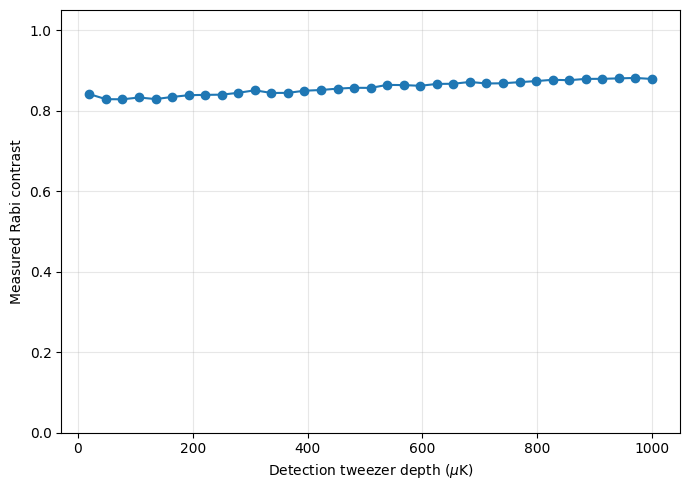

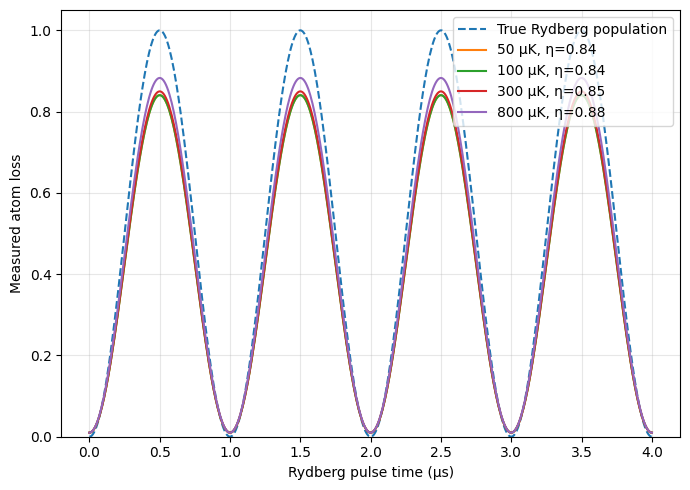

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Physical constants
# ============================================================

kB = 1.380649e-23
amu = 1.66053906660e-27

# Default: Rb-87
m = 87 * amu


# ============================================================
# Experimental parameters
# ============================================================

# Tweezer waist
w0 = 1.0e-6                 # m

# Atom temperature
T = 10e-6                   # K

# Rydberg lifetime
tau_r = 100e-6              # s

# How long tweezer is ON before we regard the atom as detected/lost
t_detection = 20e-6         # s

# Ratio:
# U_Rydberg_peak = + beta * U_ground_peak
beta = 0.25

# Ground-state false-loss probability
epsilon_g = 0.01

# Monte-Carlo atoms
N_MC = 30000

# Integration time step
dt = 20e-9                  # 20 ns


# ============================================================
# Gaussian potentials
# ============================================================

def U_ground(x, U0):
    """
    Attractive Gaussian potential
    """
    return -U0 * np.exp(-2 * x**2 / w0**2)


def U_rydberg(x, U0):
    """
    Repulsive Rydberg potential
    """
    return +beta * U0 * np.exp(-2 * x**2 / w0**2)


def force_ground(x, U0):
    """
    F = -dU/dx
    """
    return -(4 * U0 * x / w0**2) * np.exp(-2 * x**2 / w0**2)


def force_rydberg(x, U0):
    """
    Repulsive force
    """
    return +(4 * beta * U0 * x / w0**2) * np.exp(-2 * x**2 / w0**2)


# ============================================================
# Initial thermal distribution
# ============================================================

def sample_initial_state(U0, N):
    """
    Harmonic approximation near the center:

        U_g(x) ~ -U0 + 2 U0 x^2 / w0^2

    giving

        omega^2 = 4 U0 / (m w0^2)

    Thermal distributions:

        sigma_x = sqrt(kBT / (m omega^2))
        sigma_v = sqrt(kBT / m)
    """

    omega = np.sqrt(4 * U0 / (m * w0**2))

    sigma_x = np.sqrt(kB * T / (m * omega**2))
    sigma_v = np.sqrt(kB * T / m)

    x = np.random.normal(0, sigma_x, N)
    v = np.random.normal(0, sigma_v, N)

    return x, v


# ============================================================
# Rydberg -> loss mapping simulation
# ============================================================

def simulate_mapping_fidelity(U0_uK, N=N_MC):

    # convert microkelvin trap depth -> joules
    U0 = kB * U0_uK * 1e-6

    x, v = sample_initial_state(U0, N)

    # Rydberg lifetime:
    # exponential random decay time
    decay_time = np.random.exponential(tau_r, N)

    # state:
    # True  = still Rydberg
    # False = already decayed
    is_rydberg = np.ones(N, dtype=bool)

    # Whether atom has escaped
    lost = np.zeros(N, dtype=bool)

    n_steps = int(t_detection / dt)

    # use a few-waist criterion for definite escape
    escape_radius = 3.0 * w0

    for step in range(n_steps):

        t = step * dt

        active = ~lost

        # --------------------------------------------
        # Atoms still in Rydberg state
        # --------------------------------------------

        idx_r = active & is_rydberg

        if np.any(idx_r):

            a = force_rydberg(x[idx_r], U0) / m

            # velocity Verlet-ish simple step
            v[idx_r] += a * dt
            x[idx_r] += v[idx_r] * dt

        # --------------------------------------------
        # Rydberg decay
        # --------------------------------------------

        decayed_now = (
            active
            & is_rydberg
            & (t >= decay_time)
        )

        is_rydberg[decayed_now] = False

        # --------------------------------------------
        # Ground-state atoms after decay
        # --------------------------------------------

        idx_g = active & (~is_rydberg)

        if np.any(idx_g):

            a = force_ground(x[idx_g], U0) / m

            v[idx_g] += a * dt
            x[idx_g] += v[idx_g] * dt

        # --------------------------------------------
        # definite escape
        # --------------------------------------------

        escaped = np.abs(x) > escape_radius
        lost |= escaped

    # ========================================================
    # At end: determine whether atoms are actually capturable
    # ========================================================

    remaining = ~lost

    E_ground = (
        0.5 * m * v**2
        + U_ground(x, U0)
    )

    # If atom is still Rydberg after entire detection time:
    # classify as loss.
    lost[remaining & is_rydberg] = True

    # If it has decayed:
    # captured only if ground-state total energy < 0.
    decayed = remaining & (~is_rydberg)

    lost[decayed & (E_ground >= 0)] = True

    eta = np.mean(lost)

    return eta


# ============================================================
# Scan tweezer depth
# ============================================================

trap_depths_uK = np.linspace(20, 1000, 35)

eta_list = []

for U in trap_depths_uK:

    eta = simulate_mapping_fidelity(U)

    eta_list.append(eta)

    print(
        f"Trap depth = {U:7.1f} uK, "
        f"Rydberg->loss fidelity = {eta:.4f}"
    )

eta_list = np.array(eta_list)


# ============================================================
# Convert mapping fidelity to measured Rabi contrast
# ============================================================

contrast = eta_list - epsilon_g


# ============================================================
# Plot contrast vs trap depth
# ============================================================

plt.figure(figsize=(7, 5))

plt.plot(
    trap_depths_uK,
    contrast,
    "o-"
)

plt.xlabel("Detection tweezer depth ($\\mu$K)")
plt.ylabel("Measured Rabi contrast")

plt.ylim(0, 1.05)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# Show example measured Rabi oscillations
# ============================================================

Omega = 2 * np.pi * 1e6     # 1 MHz Rabi frequency

t = np.linspace(0, 4e-6, 500)

P_true = np.sin(Omega * t / 2)**2

plt.figure(figsize=(7, 5))

plt.plot(
    t * 1e6,
    P_true,
    "--",
    label="True Rydberg population"
)

# Select several trap depths
for U_test in [50, 100, 300, 800]:

    eta = simulate_mapping_fidelity(U_test)

    P_measured = (
        epsilon_g * (1 - P_true)
        + eta * P_true
    )

    plt.plot(
        t * 1e6,
        P_measured,
        label=f"{U_test} µK, η={eta:.2f}"
    )

plt.xlabel("Rydberg pulse time (µs)")
plt.ylabel("Measured atom loss")

plt.ylim(0, 1.05)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()